# Prompt Chaining Workflow
Multiple sequential LLM calls — topic → outline → blog → evaluate.

**Graph:** START → create_outline → create_blog → evaluate_blog → END

> **Before running:** add your OpenAI API key to the `.env` file.

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_community.llms.fake import FakeListLLM
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

# Mock LLM — cycles through responses (no API key needed)
model = FakeListLLM(responses=[
    "1. Introduction\n2. Historical Context\n3. Current State\n4. Challenges\n5. Future Outlook\n6. Conclusion",
    "AI in India has grown rapidly. From startups to government initiatives, India is embracing AI across sectors like healthcare, agriculture, and education. With a large talent pool and increasing investment, India is poised to become a global AI hub.",
    "8",
])

C:\Users\Deepika Yadav\AppData\Local\Temp\ipykernel_1208\610261850.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.llms.fake import FakeListLLM


## Define State

In [2]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    score: int

## Define Nodes

In [3]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f'Generate a detailed outline for a blog on the topic: {title}'
    state['outline'] = model.invoke(prompt)
    return state


def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a detailed blog on the title: {title}\nUsing the following outline:\n{outline}'
    state['content'] = model.invoke(prompt)
    return state


def evaluate_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    content = state['content']
    prompt = (
        f'Based on this outline:\n{outline}\n\n'
        f'Rate this blog on a scale of 1-10, return ONLY an integer:\n{content}'
    )
    response = model.invoke(prompt).strip()
    import re
    match = re.search(r'\d+', response)
    state['score'] = int(match.group()) if match else 0
    return state

## Build & Compile Graph

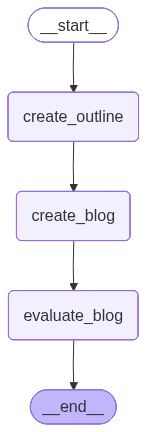

In [4]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()

from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

## Execute

In [5]:
initial_state = {
    'title': 'Rise of AI in India',
    'outline': '',
    'content': '',
    'score': 0
}

final_state = workflow.invoke(initial_state)

print('=== OUTLINE ===')
print(final_state['outline'])
print('\n=== BLOG CONTENT ===')
print(final_state['content'])
print('\n=== SCORE ===')
print(final_state['score'], '/ 10')

=== OUTLINE ===
1. Introduction
2. Historical Context
3. Current State
4. Challenges
5. Future Outlook
6. Conclusion

=== BLOG CONTENT ===
AI in India has grown rapidly. From startups to government initiatives, India is embracing AI across sectors like healthcare, agriculture, and education. With a large talent pool and increasing investment, India is poised to become a global AI hub.

=== SCORE ===
8 / 10
